# ResNet Ablation Study

- 데이터셋: Oxford-IIIT Pet
- 비교 모델: ResNet-34 / ResNet-50 vs PlainNet-34 / PlainNet-50

In [1]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

## ResNet block

- **`ResidualBlock`** : ResNet-18/34 용 기본 블록 (3x3 conv 2개)
- **`BottleneckBlock`** : ResNet-50/101/152 용 병목 블록 (1x1 -> 3x3 -> 1x1)

`use_residual` 플래그
- `use_residual=True`  -> skip connection 을 더함 (residual, 원조 ResNet)
- `use_residual=False` -> skip connection 을 제거 (plain net, Ablation 대조군)

In [2]:
class ResidualBlock(nn.Module):
    """ ResNet-34 용 기본 블록 (3x3) """
    
    expansion = 1  # 블록 출력 채널

    def __init__(self, in_channels, planes, stride=1, use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        out_channels = planes * self.expansion

        # 3x3 -> 3x3 (첫 conv 에서 stride 로 다운샘플링)
        self.conv1 = nn.Conv2d(in_channels, planes, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # shortcut
        if self.use_residual and (stride != 1 or in_channels != out_channels):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_residual:
            out = out + self.shortcut(x)
        out = self.relu(out)
        return out


In [3]:
class BottleneckBlock(nn.Module):
    """ ResNet-50 용 bottleneck 블록 (1x1 -> 3x3 -> 1x1) """
    
    expansion = 4  # 블록 출력 채널

    def __init__(self, in_channels, planes, stride=1, use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        out_channels = planes * self.expansion

        # 1x1 (채널 축소) -> 3x3 (stride 다운샘플링) -> 1x1 (채널 확장)
        self.conv1 = nn.Conv2d(in_channels, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # shortcut
        if self.use_residual and (stride != 1 or in_channels != out_channels):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.use_residual:
            out = out + self.shortcut(x)
        out = self.relu(out)
        return out


## build_resnet / build_plainnet 함수

In [4]:
class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=37, use_residual=True):
        super().__init__()
        self.in_channels = 64

        # stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # 4개 stage
        self.stage1 = self._make_stage(block, 64,  layers[0], stride=1, use_residual=use_residual)
        self.stage2 = self._make_stage(block, 128, layers[1], stride=2, use_residual=use_residual)
        self.stage3 = self._make_stage(block, 256, layers[2], stride=2, use_residual=use_residual)
        self.stage4 = self._make_stage(block, 512, layers[3], stride=2, use_residual=use_residual)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_stage(self, block, planes, num_blocks, stride, use_residual):
        """stage 하나(블록 num_blocks 개)를 nn.Sequential 로 생성"""
        strides = [stride] + [1] * (num_blocks - 1)
        blocks = []
        for s in strides:
            blocks.append(block(self.in_channels, planes, stride=s, use_residual=use_residual))
            self.in_channels = planes * block.expansion
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


In [5]:
# 블록 타입 문자열 -> 블록 클래스 매핑
BLOCK_TYPES = {
    "basic": ResidualBlock,
    "bottleneck": BottleneckBlock,
}

def build_resnet(block_type, layers, num_classes=37, use_residual=True):
    """config(block_type, layers)로 ResNet 모델 생성

    Args:
        block_type: "basic" 또는 "bottleneck"
        layers: 스테이지별 블록 수 리스트
        num_classes: 분류 클래스 수
        use_residual: True 면 residual, False 면 plain
    """
    block = BLOCK_TYPES[block_type]
    return ResNet(block, layers, num_classes=num_classes, use_residual=use_residual)

def build_plainnet(block_type, layers, num_classes=37):
    """plain network"""
    return build_resnet(block_type, layers, num_classes=num_classes, use_residual=False)


In [6]:
# ResNet 버전별 configuration
RESNET_CONFIGS = {
    "resnet_34":  ("basic",      [3, 4, 6, 3]),
    "resnet_50":  ("bottleneck", [3, 4, 6, 3]),
}

NUM_CLASSES = 37

## 모델 구조 확인 (summary)

In [7]:
resnet_34   = build_resnet(*RESNET_CONFIGS["resnet_34"], num_classes=NUM_CLASSES)
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─ResidualBlock: 2-5                [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│

In [8]:
resnet_50   = build_resnet(*RESNET_CONFIGS["resnet_50"], num_classes=NUM_CLASSES)
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 256, 56, 56]          --
│    └─BottleneckBlock: 2-5              [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│ 

In [9]:
# planeNet-34/50
plainnet_34   = build_plainnet(*RESNET_CONFIGS["resnet_34"], num_classes=NUM_CLASSES)
plainnet_50   = build_plainnet(*RESNET_CONFIGS["resnet_50"], num_classes=NUM_CLASSES)

In [10]:
# plain vs residual 파라미터 수 비교
def count_params(model):
    return sum(p.numel() for p in model.parameters())

for name, m in [("ResNet-34", resnet_34), ("PlainNet-34", plainnet_34),
                ("ResNet-50", resnet_50), ("PlainNet-50", plainnet_50)]:
    print(f"{name:12s}: {count_params(m):,} params")

ResNet-34   : 21,303,653 params
PlainNet-34 : 21,129,829 params
ResNet-50   : 23,583,845 params
PlainNet-50 : 20,807,269 params


## 데이터셋 준비

In [11]:
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [12]:
# 학습용: 증강 O
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

# 검증용: 증강 X (평가 일관성 위해 고정 변환만)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

# train/test 데이터셋 분할
trainset = torchvision.datasets.OxfordIIITPet(root="./data", split="trainval", target_types="category", download=False, transform=train_transform)
testset = torchvision.datasets.OxfordIIITPet(root="./data", split="test", target_types="category", download=False, transform=val_transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

In [13]:
# 데이터셋 확인
class_names = trainset.classes
num_classes = len(class_names)

print(f"Train dataset size: {len(trainset)}")
print(f"Test  dataset size: {len(testset)}")
print(f"Number of classes : {num_classes}")

image, label = trainset[0]
print(f"Image shape: {image.shape}")   # (C, H, W)
print(f"Label      : {label} ({class_names[label]})")

Train dataset size: 3680
Test  dataset size: 3669
Number of classes : 37
Image shape: torch.Size([3, 224, 224])
Label      : 0 (Abyssinian)


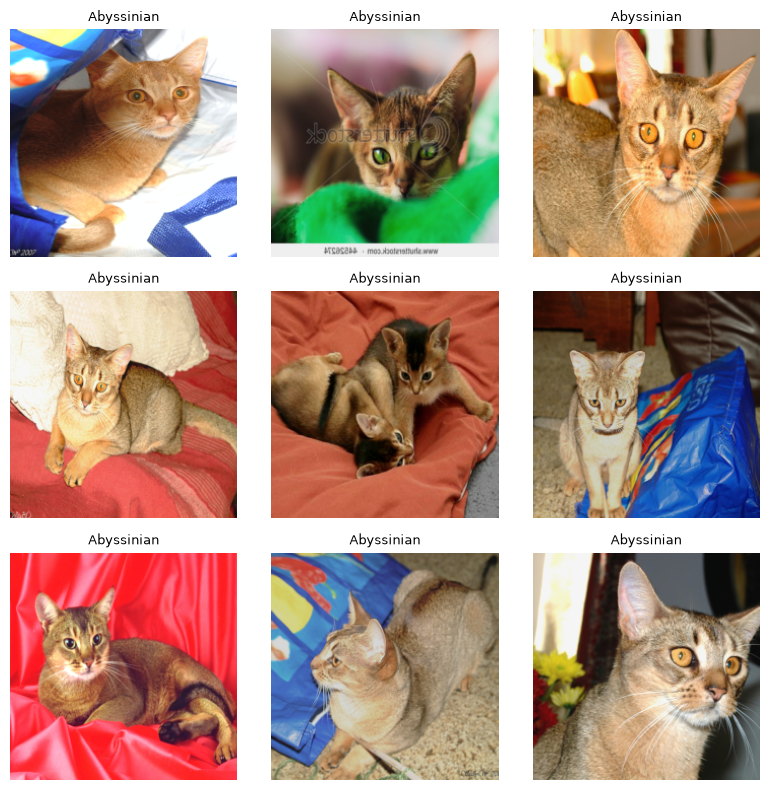

In [14]:
# 데이터 시각화
def imshow(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    npimg = img.numpy().transpose(1, 2, 0)   # (C, H, W) -> (H, W, C)
    npimg = np.clip(std * npimg + mean, 0, 1)
    return npimg

def show_samples(dataset, n_images=9):
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    axes = axes.flatten()
    for i in range(n_images):
        img, label = dataset[i]
        axes[i].imshow(imshow(img))
        axes[i].set_title(dataset.classes[label], fontsize=9)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_samples(trainset)

## 학습 (Training)

### Hyper Parameter 설정
| 항목 | 값 |
|---|---|
| Epochs | 20 |
| Batch size | 32 |
| Optimizer | SGD |
| Learning rate | 0.01 |
| Momentum | 0.9 |
| Weight decay | 1e-4 |
| lr_scheduler | CosineAnnealingLR |
| Loss | CrossEntropyLoss |
| Random seed | 42 |
| Device | CUDA (GPU) |

In [28]:
EPOCHS = 40
criterion = nn.CrossEntropyLoss()

def set_seed(seed=42):
    """ 공정한 비교를 위한 시드 고정 """
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_model(model, trainloader, testloader, epochs=EPOCHS, lr=0.01, name="model"):
    model = model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # 학습 과정 저장
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # ===== 학습 =====
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100.0 * correct / total

        # ===== 검증 =====
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                v_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                v_total += labels.size(0)
                v_correct += (predicted == labels).sum().item()

        val_loss = v_loss / v_total
        val_acc = 100.0 * v_correct / v_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{name}] Epoch {epoch + 1:2d}/{epochs}  "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"train_acc={train_acc:5.2f}%  val_acc={val_acc:5.2f}%  lr={current_lr:.4f}")

        scheduler.step()  # 매 epoch 끝에 learning rate 감쇠

    return history

histories = {}

### ResNet-34 vs PlainNet-34 vs ResNet-50 vs PlainNet-50

In [29]:
# ResNet-34
set_seed(42)
resnet_34 = build_resnet(*RESNET_CONFIGS["resnet_34"], num_classes=NUM_CLASSES)
histories["ResNet-34"] = train_model(resnet_34, trainloader, testloader, name="ResNet-34")

[ResNet-34] Epoch  1/40  train_loss=3.8583  val_loss=4.8169  train_acc= 4.10%  val_acc= 4.17%  lr=0.0100
[ResNet-34] Epoch  2/40  train_loss=3.5026  val_loss=3.4838  train_acc= 7.01%  val_acc= 6.76%  lr=0.0100
[ResNet-34] Epoch  3/40  train_loss=3.3868  val_loss=3.5801  train_acc= 8.75%  val_acc= 8.56%  lr=0.0099
[ResNet-34] Epoch  4/40  train_loss=3.2825  val_loss=3.3423  train_acc=10.43%  val_acc=10.63%  lr=0.0099
[ResNet-34] Epoch  5/40  train_loss=3.2047  val_loss=3.3223  train_acc=12.04%  val_acc=11.20%  lr=0.0098
[ResNet-34] Epoch  6/40  train_loss=3.1241  val_loss=3.1259  train_acc=12.80%  val_acc=13.25%  lr=0.0096
[ResNet-34] Epoch  7/40  train_loss=3.0120  val_loss=3.1360  train_acc=15.30%  val_acc=15.13%  lr=0.0095
[ResNet-34] Epoch  8/40  train_loss=2.9372  val_loss=3.1145  train_acc=16.79%  val_acc=14.15%  lr=0.0093
[ResNet-34] Epoch  9/40  train_loss=2.8219  val_loss=3.0111  train_acc=19.48%  val_acc=16.52%  lr=0.0090
[ResNet-34] Epoch 10/40  train_loss=2.7709  val_loss=2.

In [17]:
# PlainNet-34
set_seed(42)
plainnet_34 = build_plainnet(*RESNET_CONFIGS["resnet_34"], num_classes=NUM_CLASSES)
histories["PlainNet-34"] = train_model(plainnet_34, trainloader, testloader, name="PlainNet-34")

[PlainNet-34] Epoch  1/20  train_loss=3.6749  val_loss=3.7260  train_acc= 2.45%  val_acc= 3.16%  lr=0.0100
[PlainNet-34] Epoch  2/20  train_loss=3.6075  val_loss=3.5982  train_acc= 2.96%  val_acc= 4.42%  lr=0.0099
[PlainNet-34] Epoch  3/20  train_loss=3.5646  val_loss=3.5528  train_acc= 3.42%  val_acc= 4.61%  lr=0.0098
[PlainNet-34] Epoch  4/20  train_loss=3.5438  val_loss=3.4965  train_acc= 3.75%  val_acc= 5.31%  lr=0.0095
[PlainNet-34] Epoch  5/20  train_loss=3.5203  val_loss=3.5139  train_acc= 4.62%  val_acc= 4.50%  lr=0.0090
[PlainNet-34] Epoch  6/20  train_loss=3.5035  val_loss=3.5074  train_acc= 5.22%  val_acc= 4.80%  lr=0.0085
[PlainNet-34] Epoch  7/20  train_loss=3.4895  val_loss=3.4711  train_acc= 5.52%  val_acc= 5.53%  lr=0.0079
[PlainNet-34] Epoch  8/20  train_loss=3.4676  val_loss=3.4345  train_acc= 5.68%  val_acc= 7.74%  lr=0.0073
[PlainNet-34] Epoch  9/20  train_loss=3.4201  val_loss=3.4090  train_acc= 6.98%  val_acc= 6.11%  lr=0.0065
[PlainNet-34] Epoch 10/20  train_loss

In [21]:
# ResNet-50
set_seed(42)
resnet_50 = build_resnet(*RESNET_CONFIGS["resnet_50"], num_classes=NUM_CLASSES)
histories["ResNet-50"] = train_model(resnet_50, trainloader, testloader, name="ResNet-50")

[ResNet-50] Epoch  1/20  train_loss=4.0898  val_loss=3.9156  train_acc= 2.77%  val_acc= 4.01%  lr=0.0100
[ResNet-50] Epoch  2/20  train_loss=3.6032  val_loss=3.7930  train_acc= 5.49%  val_acc= 5.61%  lr=0.0099
[ResNet-50] Epoch  3/20  train_loss=3.4783  val_loss=4.1508  train_acc= 6.66%  val_acc= 6.90%  lr=0.0098
[ResNet-50] Epoch  4/20  train_loss=3.3941  val_loss=3.6980  train_acc= 7.85%  val_acc= 8.12%  lr=0.0095
[ResNet-50] Epoch  5/20  train_loss=3.3480  val_loss=3.8595  train_acc= 8.94%  val_acc= 9.57%  lr=0.0090
[ResNet-50] Epoch  6/20  train_loss=3.2466  val_loss=4.0716  train_acc=10.05%  val_acc=11.09%  lr=0.0085
[ResNet-50] Epoch  7/20  train_loss=3.1598  val_loss=3.8627  train_acc=11.96%  val_acc= 7.96%  lr=0.0079
[ResNet-50] Epoch  8/20  train_loss=3.0894  val_loss=3.7855  train_acc=14.38%  val_acc=13.98%  lr=0.0073
[ResNet-50] Epoch  9/20  train_loss=2.9728  val_loss=3.5481  train_acc=15.84%  val_acc=14.72%  lr=0.0065
[ResNet-50] Epoch 10/20  train_loss=2.8936  val_loss=4.

In [19]:
# PlainNet-50
set_seed(42)
plainnet_50 = build_plainnet(*RESNET_CONFIGS["resnet_50"], num_classes=NUM_CLASSES)
histories["PlainNet-50"] = train_model(plainnet_50, trainloader, testloader, name="PlainNet-50")

[PlainNet-50] Epoch  1/20  train_loss=3.7555  val_loss=3.7795  train_acc= 2.58%  val_acc= 2.83%  lr=0.0100
[PlainNet-50] Epoch  2/20  train_loss=3.6344  val_loss=3.6361  train_acc= 2.64%  val_acc= 2.78%  lr=0.0099
[PlainNet-50] Epoch  3/20  train_loss=3.6165  val_loss=3.6044  train_acc= 3.23%  val_acc= 3.82%  lr=0.0098
[PlainNet-50] Epoch  4/20  train_loss=3.5991  val_loss=3.6098  train_acc= 3.32%  val_acc= 3.03%  lr=0.0095
[PlainNet-50] Epoch  5/20  train_loss=3.5665  val_loss=3.5639  train_acc= 3.97%  val_acc= 4.42%  lr=0.0090
[PlainNet-50] Epoch  6/20  train_loss=3.5373  val_loss=3.5890  train_acc= 4.57%  val_acc= 4.52%  lr=0.0085
[PlainNet-50] Epoch  7/20  train_loss=3.4993  val_loss=3.5682  train_acc= 4.78%  val_acc= 5.07%  lr=0.0079
[PlainNet-50] Epoch  8/20  train_loss=3.4547  val_loss=3.5433  train_acc= 6.44%  val_acc= 6.16%  lr=0.0073
[PlainNet-50] Epoch  9/20  train_loss=3.4324  val_loss=3.4347  train_acc= 6.41%  val_acc= 6.65%  lr=0.0065
[PlainNet-50] Epoch 10/20  train_loss

## Ablation Study 결과

In [26]:
from IPython.display import Markdown, display

# 모델별 메타정보 (블록 타입, skip connection 유무)
model_meta = {
    "ResNet-34":   ("basic",      "O"),
    "PlainNet-34": ("basic",      "X"),
    "ResNet-50":   ("bottleneck", "O"),
    "PlainNet-50": ("bottleneck", "X"),
}

# best val_acc 기준 결과표
header = ("| 모델 | 블록 | skip | best val_acc | epoch |\n"
         "|---|---|:--:|---:|:--:|\n")
rows = ""
for name in ["ResNet-34", "PlainNet-34", "ResNet-50", "PlainNet-50"]:
    h = histories[name]
    best = max(h["val_acc"])
    best_ep = h["val_acc"].index(best) + 1
    blk, skip = model_meta[name]
    rows += f"| {name} | {blk} | {skip} | {best:.2f}% | {best_ep} |\n"

display(Markdown(header + rows))


| 모델 | 블록 | skip | best val_acc | epoch |
|---|---|:--:|---:|:--:|
| ResNet-34 | basic | O | 42.82% | 19 |
| PlainNet-34 | basic | X | 14.01% | 20 |
| ResNet-50 | bottleneck | O | 32.19% | 20 |
| PlainNet-50 | bottleneck | X | 10.33% | 19 |


In [23]:
# Ablation: skip connection 의 효과 (best val_acc 기준)
print("=== Ablation Study: residual vs plain (best val_acc) ===\n")
for depth in ["34", "50"]:
    r = max(histories[f"ResNet-{depth}"]["val_acc"])
    p = max(histories[f"PlainNet-{depth}"]["val_acc"])
    print(f"[Depth {depth}]  ResNet {r:5.2f}%  vs  PlainNet {p:5.2f}%  "
          f"->  skip connection 효과: {r - p:+.2f}%p")


=== Ablation Study: residual vs plain (best val_acc) ===

[Depth 34]  ResNet 42.82%  vs  PlainNet 14.01%  ->  skip connection 효과: +28.81%p
[Depth 50]  ResNet 32.19%  vs  PlainNet 10.33%  ->  skip connection 효과: +21.86%p


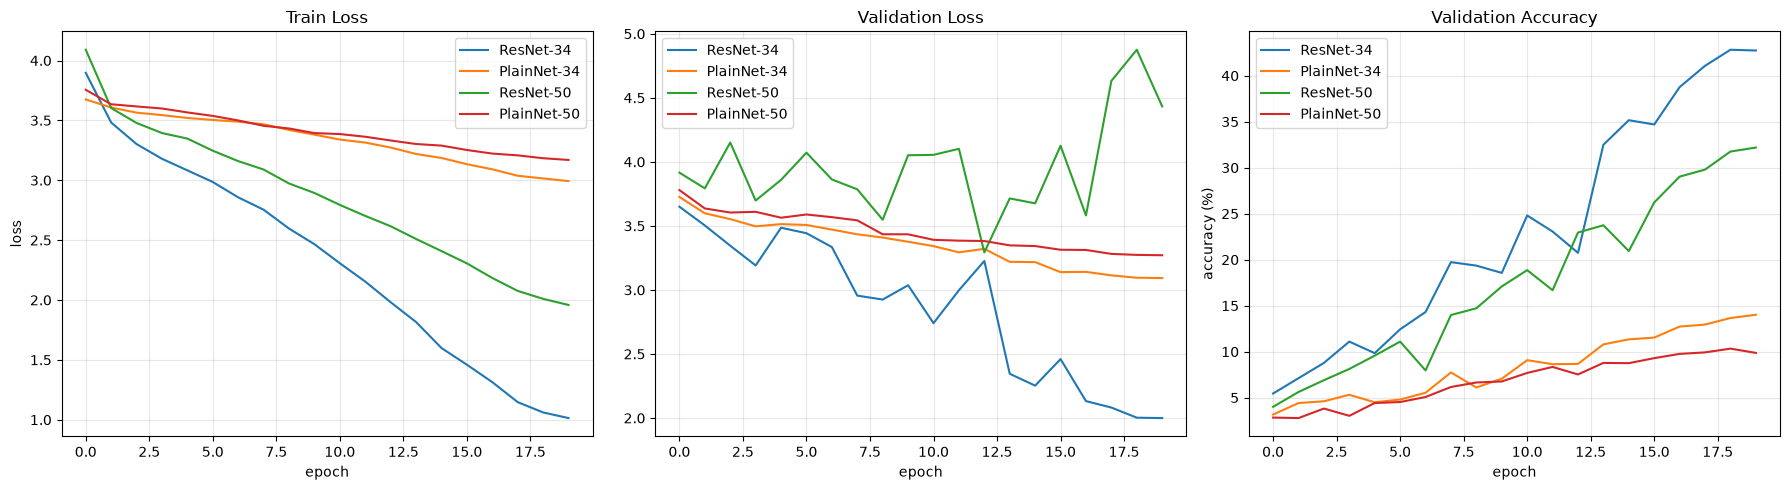

In [24]:
# 학습 곡선 시각화 (train loss / val loss / val accuracy)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, h in histories.items():
    axes[0].plot(h["train_loss"], label=name)
    axes[1].plot(h["val_loss"], label=name)
    axes[2].plot(h["val_acc"], label=name)

axes[0].set_title("Train Loss")
axes[1].set_title("Validation Loss")
axes[2].set_title("Validation Accuracy")
axes[0].set_ylabel("loss")
axes[2].set_ylabel("accuracy (%)")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---

## Ablation Study 분석

| depth | ResNet | PlainNet | 차이 |
|---|---:|---:|---:|
| 34 | 42.82% | 14.01% | **+28.81%p** |
| 50 | 32.19% | 10.33% | **+21.86%p** |

### 1. skip connection이 성능을 결정한다 (residual > plain)
동일 조건에서 skip connection 유무만 다른데, residual 모델이 plain 모델보다 34에서 **+28.8%p**, 50에서 **+21.9%p**로 Validation Accuracy가 더 높았다. 두 depth 모두에서 잔차 연결이 성능의 결정적 요인임을 확인했다.

### 2. plain net은 학습이 안 된다 (degradation problem)
Train Loss 그래프에서 PlainNet은 loss가 거의 안 떨어진다(3.0~3.2에서 정체). 즉 plain net의 문제는 과적합이 아니라 최적화 자체가 어려운 것이다. skip connection이 없으면 gradient가 깊은 층까지 잘 전달되지 않아, 학습 데이터조차 제대로 맞추지 못한다. 이것이 ResNet 논문이 지적한 **degradation problem**이며, residual 연결이 이를 해결함을 실증했다.

### 3. plain은 깊을수록 더 나빠진다
PlainNet-50(10.33%) < PlainNet-34(14.01%). 층을 더 쌓은 plain net이 오히려 더 못했다 — 깊어질수록 최적화가 더 어려워진다는 degradation 현상과 일치한다. 반면 residual은 두 depth 모두에서 정상적으로 학습되었다.

### 4. 이 실험 조건에서는 ResNet-34 > ResNet-50
일반적으로는 더 깊은 ResNet-50이 유리하지만, 여기서는 ResNet-34(42.8%)가 ResNet-50(32.2%)보다 높았다. 원인은 소규모 데이터(~3,680장)이다. 용량이 큰 ResNet-50은 적은 데이터에서 학습이 불안정했고(Validation Loss 그래프에서 ResNet-50 곡선이 크게 진동), ResNet-34는 훨씬 안정적으로 수렴했다.

### 결론
skip connection은 심층 신경망 학습의 핵심 요소다. 잔차 연결로 degradation problem을 해결할 수 있다.

---

## 실험 기록

### 1. Overfitting 발생 및 데이터 증강 적용

**문제**

ResNet-34를 10 epoch 학습한 결과, train은 계속 좋아지는데 val_loss는 증가하는 overfitting을 확인했다.

```
[ResNet-34] Epoch  7/30  train_loss=0.9171  val_loss=4.2100  train_acc=70.19%  val_acc=21.67%
[ResNet-34] Epoch  8/30  train_loss=0.7840  val_loss=4.1980  train_acc=74.92%  val_acc=19.57%
[ResNet-34] Epoch  9/30  train_loss=0.5057  val_loss=4.8045  train_acc=83.04%  val_acc=22.29%
[ResNet-34] Epoch 10/30  train_loss=0.3673  val_loss=5.8078  train_acc=87.77%  val_acc=19.24%
```

- `train_loss`는 꾸준히 하강하는데 **`val_loss`는 epoch 7부터 다시 상승**(4.21 → 5.80)
→ 과적합 발생!

**원인 분석**
- Oxford-IIIT Pet의 train dataset은 약 3,680장(클래스당 ~100장) 으로 소규모인데, 모델을 from scratch로 학습
- 데이터 증강이 없어 모델이 학습 이미지 자체를 암기 → 일반화 실패

**해결 방안**

train 데이터에 데이터 증강을 추가하여 과적합을 완화하고 데이터 다양성을 확보했다.
(validation은 평가 일관성을 위해 증강 없이 유지)

- `RandomResizedCrop(224)` : 위치/스케일 변화
- `RandomHorizontalFlip()` : 좌우 반전
- `ColorJitter(...)` : 색상/밝기 변화

**결과 (증강 적용 후)**

데이터 증강 후 과적합이 완화되었다.

| 구분 | train_acc | best val_acc | val_loss 경향 |
|---|---:|---:|---|
| 증강 전 | ~87% | ~19% | epoch 7부터 발산 (4.2 → 5.8) |
| 증강 후 | ~79% | ~43% | 안정 (2.0~3.5 범위, 발산 없음) |

- train/val 차이가 68%p(87→19) → 약 36%p(79→43)로 절반 가까이 줄어듦
- 학습이 진행돼도 val_loss가 더 이상 폭증하지 않음
- val_acc 약 2배 향상(~19% → ~43%)

---

### 2. Learning Rate Scheduler(CosineAnnealingLR) 적용

**관찰**

learning rate를 고정(0.1)한 채 학습하니, train은 안정적으로 좋아지는데 val accuracy가 epoch마다 크게 진동하여 모델 간 비교가 어려웠다.

```
[ResNet-34] Epoch 11/20  train_loss=1.2887  val_loss=2.1086  train_acc=60.65%  val_acc=42.41%
[ResNet-34] Epoch 14/20  train_loss=1.0380  val_loss=2.0466  train_acc=68.23%  val_acc=46.42%
[ResNet-34] Epoch 15/20  train_loss=0.9066  val_loss=2.5432  train_acc=70.98%  val_acc=36.20%
[ResNet-34] Epoch 17/20  train_loss=0.7841  val_loss=3.5868  train_acc=75.33%  val_acc=33.44%
[ResNet-34] Epoch 18/20  train_loss=0.7481  val_loss=2.3075  train_acc=76.14%  val_acc=44.92%
[ResNet-34] Epoch 20/20  train_loss=0.6150  val_loss=2.3607  train_acc=79.48%  val_acc=46.01%
```

- `val_acc`가 **42 → 46 → 36 → 33 → 45 → 46** 으로 ±10%씩 요동치고, `val_loss`도 epoch 17에서 3.59로 급등
→ 학습 후반에 최소점으로 안착하지 못하고 튕김

**원인 분석**
- learning rate를 고정하면 학습 후반에도 보폭(step)이 커서 최소점 주변을 계속 진동
- 진동이 크면 "마지막 epoch 값"이 운에 좌우되어, skip connection 유무를 비교하는 Ablation의 공정성이 흔들림

**해결 방법**

CosineAnnealingLR로 learning rate를 epoch에 따라 서서히 0에 가깝게 감쇠시켜, 학습 후반에 최소점으로 부드럽게 안착하도록 했다.

- `optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)`
- 매 epoch 끝에 `scheduler.step()` 호출 → lr이 코사인 곡선으로 감소
- 후반 진동 완화 → 안정적이고 비교 가능한 최종 성능 확보

**결과 (스케줄러 적용 후)**

learning rate 감쇠 후 validation 곡선의 진동이 사라지고 안정적으로 수렴했다.

| 구분 | val_acc 후반 거동 | best vs final |
|---|---|---|
| 스케줄러 전 (lr=0.1 고정) | 33~46% 사이 ±10%씩 진동, val_loss 급등(3.59) | best 46.4% ↔ 중간중간 33%로 붕괴 |
| 스케줄러 후 (Cosine) | 매끄럽게 상승 후 안착, 급등 없음 | best 42.82% ≈ final 42.74% |

- 최고 성능과 마지막 epoch 성능이 거의 일치 → 곡선이 튀지 않고 최소점에 안착
- 4개 모델 모두 best와 final 차이가 미미해, 모델 간 비교에 신뢰성이 생김